In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



     student_id  math  science  english  attendance_percent
0             1    77       96       47                  79
1             2    83       65       63                  72
2             3    52       61       79                  85
3             4    48       79       83                  73
4             5    49       72       52                  76
..          ...   ...      ...      ...                 ...
195         196    93       52       93                  92
196         197    60       96       57                  70
197         198    50       99       50                  92
198         199    72       66       48                  93
199         200    95       52       88                  65

[200 rows x 5 columns]


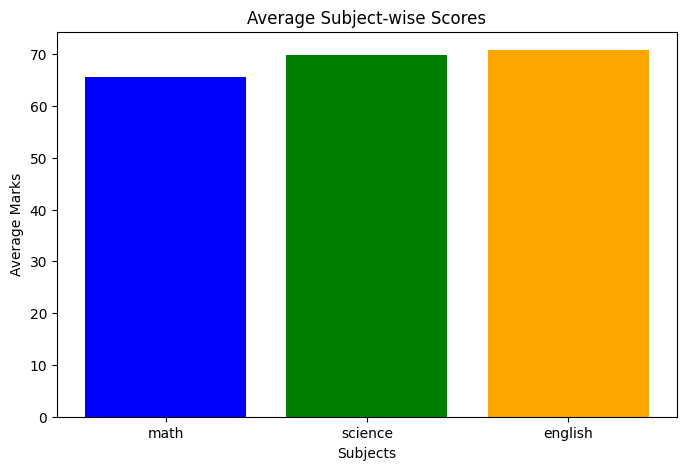

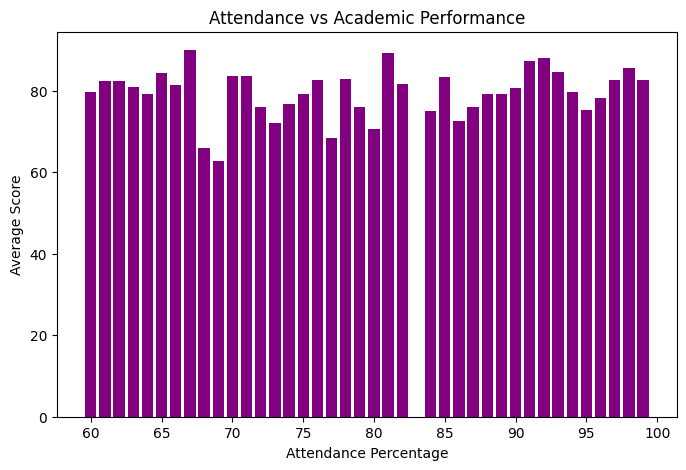

In [6]:

np.random.seed(1)  

num_students = 200

data = {
    "student_id": range(1, num_students + 1),
    "math": np.random.randint(40, 100, num_students),
    "science": np.random.randint(40, 100, num_students),
    "english": np.random.randint(40, 100, num_students),
    "attendance_percent": np.random.randint(60, 100, num_students)
}

df = pd.DataFrame(data)
print(df)

# averarge
df["total_score"] = df["math"] + df["science"] + df["english"]
df["average_score"] = df["total_score"] / 3

# Performance classification
def classify_performance(avg):
    if avg >= 75:
        return "Excellent"
    elif avg >= 60:
        return "Good"
    elif avg >= 50:
        return "Average"
    else:
        return "Poor"

df["performance"] = df["average_score"].apply(classify_performance)



# Weighted score
# Math = 40%, Science = 35%, English = 25%
weights = np.array([0.4, 0.35, 0.25])

scores = df[["math", "science", "english"]].values
df["weighted_score"] = np.dot(scores, weights)

# Standardization (Z-score)
df["math_std"] = (df["math"] - df["math"].mean()) / df["math"].std()
df["science_std"] = (df["science"] - df["science"].mean()) / df["science"].std()
df["english_std"] = (df["english"] - df["english"].mean()) / df["english"].std()

# -------------------------------
# 4. Visualizations (Matplotlib)
# -------------------------------

# Subject-wise average comparison
subject_means = df[["math", "science", "english"]].mean()

plt.figure(figsize=(8, 5))
plt.bar(subject_means.index, subject_means.values, color=["blue", "green", "orange"])
plt.title("Average Subject-wise Scores")
plt.ylabel("Average Marks")
plt.xlabel("Subjects")
plt.show()

# Attendance vs Academic Performance
plt.figure(figsize=(8, 5))
plt.bar(df["attendance_percent"], df["average_score"], color="purple")
plt.title("Attendance vs Academic Performance")
plt.xlabel("Attendance Percentage")
plt.ylabel("Average Score")
plt.show()


# print("Sample Data:")
# print(df.head())

# print("\nPerformance Distribution:")
# print(df["performance"].value_counts())
